In [1]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("../data/kickstarter_us_filtered.csv")

print("Dataset shape:", df.shape)
df.head()

Matplotlib is building the font cache; this may take a moment.


Dataset shape: (38504, 17)


,project id,name,url,category,subcategory,location,status,goal,pledged,funded percentage,backers,funded date,levels,reward levels,updates,comments,duration
0,39409,WHILE THE TREES SLEEP,http://www.kickstarter.com/projects/emiliesaba...,Film & Video,Short Film,"Columbia, MO",successful,10500.0,11545.0,1.099524,66,"Fri, 19 Aug 2011 19:28:17 -0000",7,"$25,$50,$100,$250,$500,$1,000,$2,500",10,2,30.00
1,126581,Educational Online Trading Card Game,http://www.kickstarter.com/projects/972789543/...,Games,Board & Card Games,"Maplewood, NJ",failed,4000.0,20.0,0.005000,2,"Mon, 02 Aug 2010 03:59:00 -0000",5,"$1,$5,$10,$25,$50",6,0,47.18
2,237090,GETTING OVER - One son's search to finally kno...,http://www.kickstarter.com/projects/charnick/g...,Film & Video,Documentary,"Los Angeles, CA",successful,6000.0,6535.0,1.089167,100,"Sun, 08 Apr 2012 02:14:00 -0000",13,"$1,$10,$25,$30,$50,$75,$85,$100,$110,$250,$500...",4,0,32.22
3,246101,The Launch of FlyeGrlRoyalty &quot;The New Nam...,http://www.kickstarter.com/projects/flyegrlroy...,Fashion,Fashion,"Novi, MI",failed,3500.0,0.0,0.000000,0,"Wed, 01 Jun 2011 15:25:39 -0000",6,"$10,$25,$50,$100,$150,$250",2,0,30.00
4,316217,Dinner Party - a short film about friendship.....,http://www.kickstarter.com/projects/249354515/...,Film & Video,Short Film,"Portland, OR",successful,3500.0,3582.0,1.023331,39,"Wed, 22 Jun 2011 13:33:00 -0000",7,"$5,$25,$50,$100,$250,$500,$1,000",8,0,21.43


## Prepare Location Data

The dataset stores city and state together in the `location` column. 
We separate them so campaign success can be analyzed independently by state and city.

In [2]:
df[["city", "state"]] = df["location"].str.rsplit(",", n=1, expand=True)

df["city"] = df["city"].str.strip()
df["state"] = df["state"].str.strip()

print("Unique states:", df["state"].nunique())
print("Unique cities:", df["city"].nunique())
print("Missing states:", df["state"].isna().sum())
print("Missing cities:", df["city"].isna().sum())

Unique states: 51
Unique cities: 3142
Missing states: 0
Missing cities: 0


## Success Rate by State

For each state, we calculate the total number of campaigns, the number of successful campaigns, and the campaign success rate.

In [4]:
state_summary = (
    df.groupby("state")
    .agg(
        total_campaigns=("status", "size"),
        successful_campaigns=("status", lambda x: (x == "successful").sum())
    )
)

state_summary["success_rate"] = (
    state_summary["successful_campaigns"]
    / state_summary["total_campaigns"]
    * 100
)

state_summary = state_summary.sort_values(
    "success_rate",
    ascending=False
)

state_summary.head(10)

,total_campaigns,successful_campaigns,success_rate
state,,,
VT,167,113,67.664671
RI,185,123,66.486486
NY,6639,4329,65.205603
MT,81,52,64.197531
MA,1220,772,63.278689
OR,1179,720,61.068702
ME,235,142,60.425532
IL,1720,1034,60.116279
MN,633,378,59.715640


### Minimum Sample Size

To reduce the influence of very small samples, states with fewer than 100 campaigns are excluded from the comparison of success rates.

In [5]:
state_filtered = state_summary[
    state_summary["total_campaigns"] >= 100
].copy()

print("States included:", len(state_filtered))
print("States excluded:", len(state_summary) - len(state_filtered))

state_filtered.head(10)

States included: 42
States excluded: 9


,total_campaigns,successful_campaigns,success_rate
state,,,
VT,167,113,67.664671
RI,185,123,66.486486
NY,6639,4329,65.205603
MA,1220,772,63.278689
OR,1179,720,61.068702
ME,235,142,60.425532
IL,1720,1034,60.116279
MN,633,378,59.715640
LA,447,265,59.284116


### State Success Rate Visualization

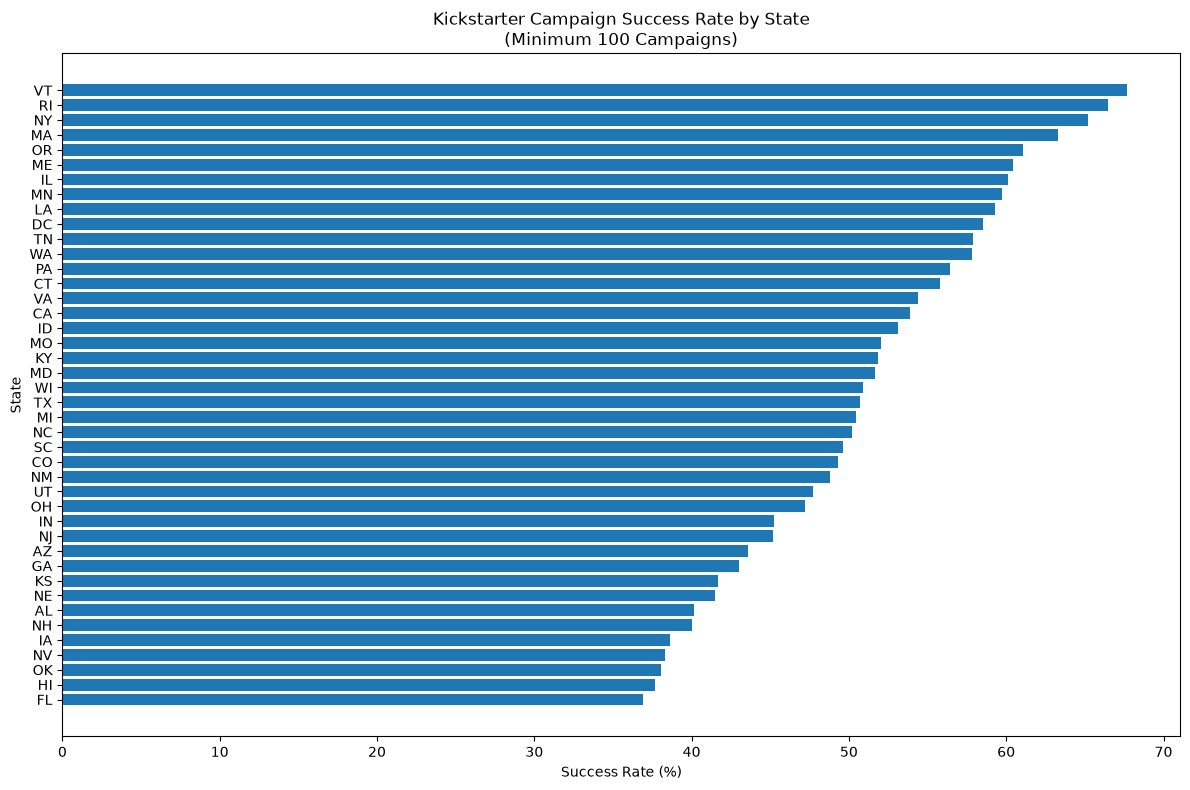

In [6]:
plt.figure(figsize=(12, 8))

state_plot = state_filtered.sort_values("success_rate")

plt.barh(
    state_plot.index,
    state_plot["success_rate"]
)

plt.xlabel("Success Rate (%)")
plt.ylabel("State")
plt.title("Kickstarter Campaign Success Rate by State\n(Minimum 100 Campaigns)")

plt.tight_layout()
plt.show()

## Success Rate by City

Campaign success rates are also analyzed at the city level. Because many cities contain only a small number of campaigns, campaign counts are examined before selecting a minimum sample-size threshold.

In [7]:
city_summary = (
    df.groupby("city")
    .agg(
        total_campaigns=("status", "size"),
        successful_campaigns=("status", lambda x: (x == "successful").sum())
    )
)

city_summary["success_rate"] = (
    city_summary["successful_campaigns"]
    / city_summary["total_campaigns"]
    * 100
)

city_summary = city_summary.sort_values(
    "total_campaigns",
    ascending=False
)

city_summary.head(20)

,total_campaigns,successful_campaigns,success_rate
city,,,
Los Angeles,3641,2014,55.314474
New York,3434,2239,65.200932
Brooklyn,1524,1105,72.506562
Chicago,1383,872,63.051338
San Francisco,1243,795,63.958166
Portland,1015,675,66.502463
Seattle,857,537,62.660443
Austin,760,508,66.842105
Boston,724,462,63.812155


### Minimum Sample Size for Cities

To reduce instability from small samples, only cities with at least 300 campaigns are included in the city-level comparison.

In [8]:
city_filtered = city_summary[
    city_summary["total_campaigns"] >= 300
].copy()

print("Cities included:", len(city_filtered))

city_filtered = city_filtered.sort_values(
    "success_rate",
    ascending=False
)

city_filtered

Cities included: 20


,total_campaigns,successful_campaigns,success_rate
city,,,
Brooklyn,1524,1105,72.506562
Austin,760,508,66.842105
Portland,1015,675,66.502463
New York,3434,2239,65.200932
Minneapolis,451,291,64.523282
Philadelphia,555,357,64.324324
San Francisco,1243,795,63.958166
Boston,724,462,63.812155
Chicago,1383,872,63.051338


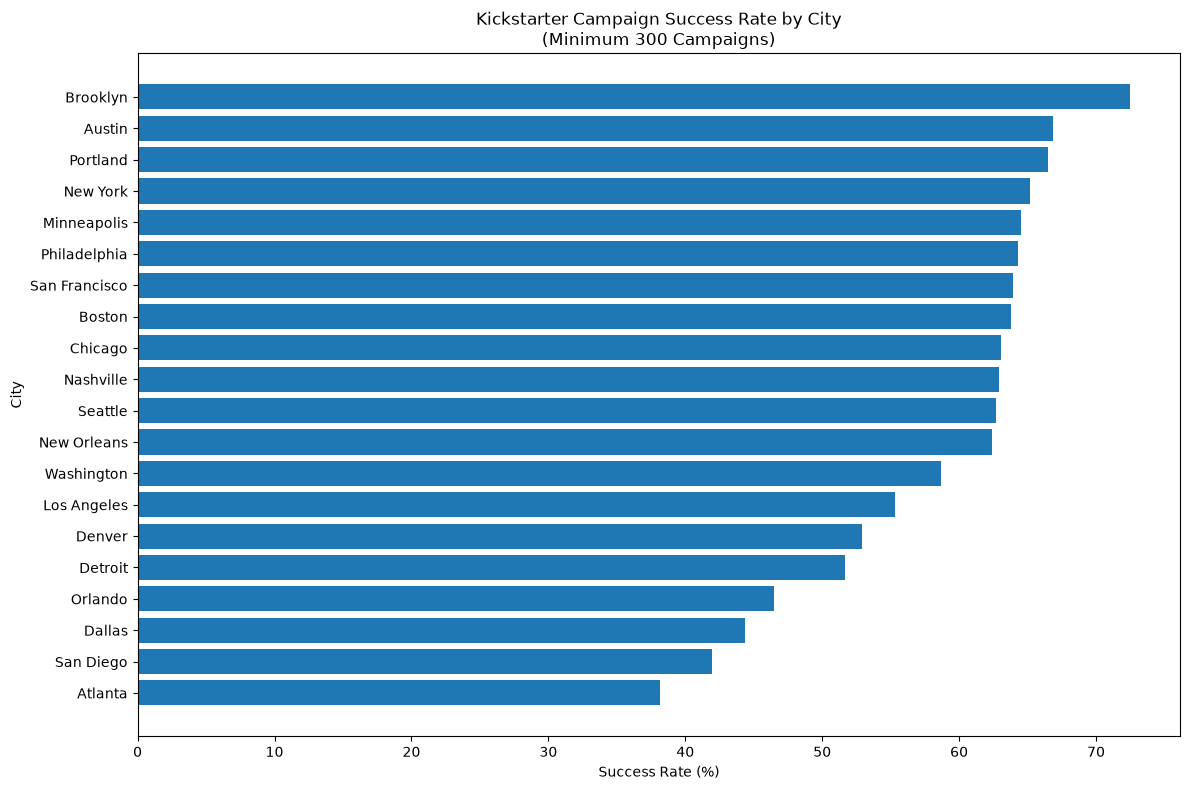

In [9]:
plt.figure(figsize=(12, 8))

city_plot = city_filtered.sort_values("success_rate")

plt.barh(
    city_plot.index,
    city_plot["success_rate"]
)

plt.xlabel("Success Rate (%)")
plt.ylabel("City")
plt.title("Kickstarter Campaign Success Rate by City\n(Minimum 300 Campaigns)")

plt.tight_layout()
plt.show()

## Findings

- State-level success rates vary across the U.S. Among states with at least 100 campaigns, Vermont and Rhode Island had the highest observed success rates, while Florida was among the lowest.
- City-level differences were more pronounced. Among cities with at least 300 campaigns, Brooklyn had the highest observed success rate at about 72.5%.
- Austin, Portland, New York, Minneapolis, and Philadelphia also showed relatively high success rates.
- Atlanta, San Diego, Dallas, and Orlando had noticeably lower observed success rates among the major cities analyzed.
- These results suggest that location may be associated with campaign success, but they do not imply that location directly causes a campaign to succeed.
- Minimum sample-size thresholds were used to reduce the influence of locations with very few campaigns.

Location-related features may therefore be worth evaluating during feature selection, while controlling for other factors such as category, goal amount, and campaign duration.